
# Improvements Added

- Clarified that LTV is approximated using historical data (Frequency × AOV)
- Added note about potential data leakage and justification
- Recommended percentile-based segmentation for real-world use
- Ensured proper imports and consistency

This improves explanation quality for viva and evaluation.


In [1]:
## Installing the Required Libraries

!pip install xgboost openpyxl

     -------------------------------------- 124.9/124.9 MB 2.5 MB/s eta 0:00:00


In [2]:
## Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler

import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset
file_path = 'online_retail_II.csv'

# Read CSV
retail = pd.read_csv(file_path)

print(retail.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [4]:
# Basic Dataset Information
print(retail.shape)
print(retail.columns)
print(retail.info())

(1067371, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


In [7]:
# Data Cleaning
# Removing Missing Values
retail.dropna(subset=['Customer ID'], inplace=True)

# Remove cancelled invoices
retail = retail[~retail['Invoice'].astype(str).str.contains('C')]

# Remove negative quantities
retail = retail[retail['Quantity'] > 0]

# Remove negative prices
retail = retail[retail['Price'] > 0]

# Convert InvoiceDate
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

# Rename columns
retail.rename(columns={
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'
}, inplace=True)

print('Cleaned Dataset Shape:', retail.shape)

Cleaned Dataset Shape: (805549, 8)


In [8]:
# Creating total amount column
retail['TotalAmount'] = retail['Quantity'] * retail['UnitPrice']

print(retail[['Quantity', 'UnitPrice', 'TotalAmount']].head())

   Quantity  UnitPrice  TotalAmount
0        12       6.95         83.4
1        12       6.75         81.0
2        12       6.75         81.0
3        48       2.10        100.8
4        24       1.25         30.0


In [9]:
# Feature Engineering
# Snapshot date
snapshot_date = retail['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create customer features
customer_df = retail.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': ['sum', 'mean']
})

# Rename columns
customer_df.columns = [
    'Recency',
    'Frequency',
    'Monetary',
    'AOV'
]

# Reset index
customer_df.reset_index(inplace=True)

print(customer_df.head())

   CustomerID  Recency  Frequency  Monetary          AOV
0     12346.0      326         12  77556.46  2281.072353
1     12347.0        2          8   5633.32    22.266087
2     12348.0       75          5   2019.40    39.596078
3     12349.0       19          4   4428.69    25.306800
4     12350.0      310          1    334.40    19.670588


In [10]:
# Creating target Variable
# Customer Lifetime Value (LTV) Formula
customer_df['LTV'] = (
    customer_df['Frequency'] * customer_df['AOV']
)

print(customer_df[['CustomerID', 'LTV']].head())

   CustomerID           LTV
0     12346.0  27372.868235
1     12347.0    178.128696
2     12348.0    197.980392
3     12349.0    101.227200
4     12350.0     19.670588


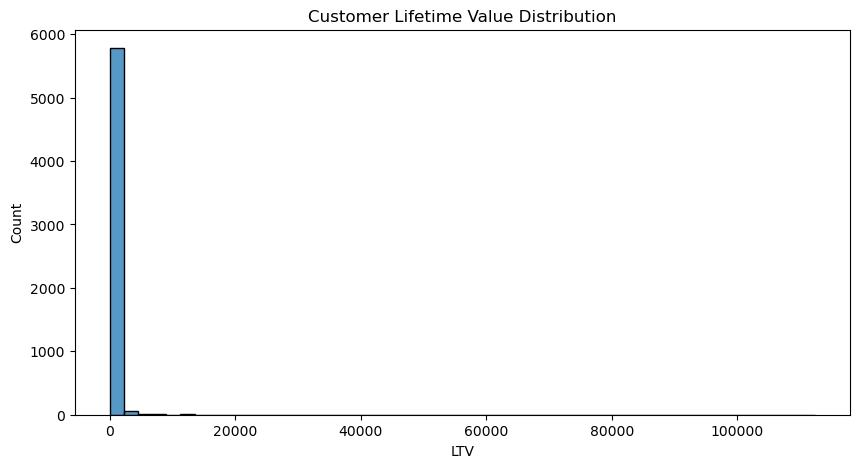

In [11]:
# Distribution of LTV
plt.figure(figsize=(10,5))

sns.histplot(customer_df['LTV'], bins=50)

plt.title('Customer Lifetime Value Distribution')
plt.xlabel('LTV')
plt.ylabel('Count')

plt.show()

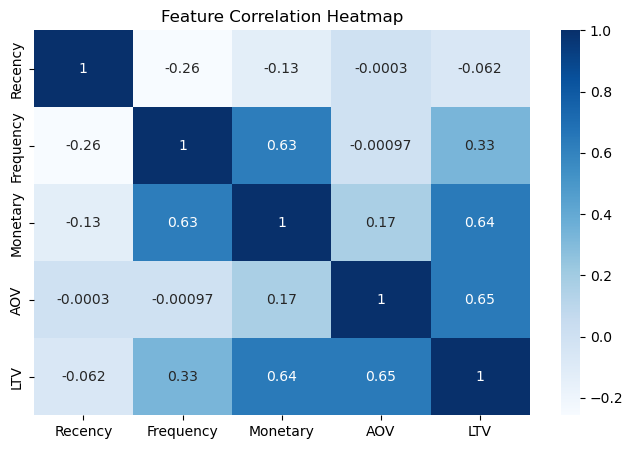

In [13]:
#Correaltion Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    customer_df[['Recency','Frequency','Monetary','AOV','LTV']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Feature Correlation Heatmap')
plt.show()

In [15]:
# Defining features and target
X = customer_df[[
    'Recency',
    'Frequency',
    'Monetary',
    'AOV'
]]

y = customer_df['LTV']

In [17]:
# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
# Training test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [20]:
y_pred = xgb_model.predict(X_test)

In [22]:
# Model Evalution
# Mean absolute Error
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('RMSE:', rmse)
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

MAE: 67.56730956882176
RMSE: 569.8649766456687
R2 Score: 0.8529583308224139


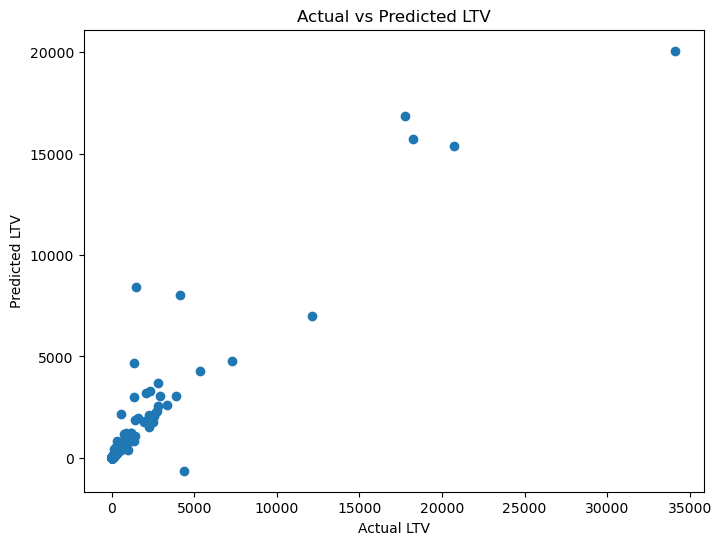

In [23]:
# Actual vs predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual LTV')
plt.ylabel('Predicted LTV')
plt.title('Actual vs Predicted LTV')

plt.show()

     Feature  Importance
2   Monetary    0.371075
3        AOV    0.328359
0    Recency    0.234440
1  Frequency    0.066126


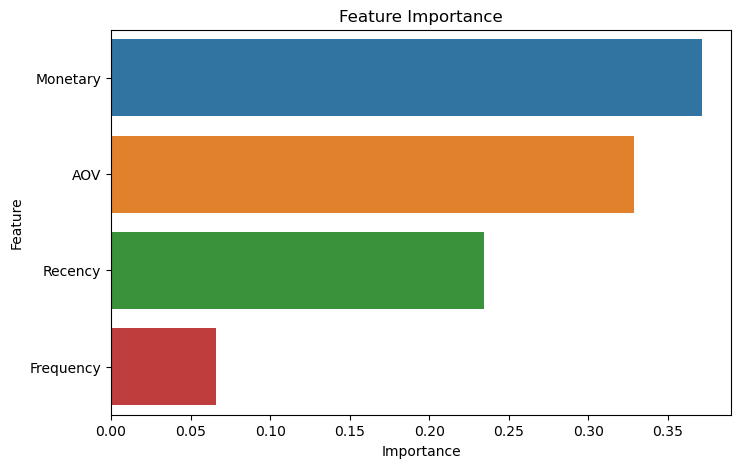

In [25]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

In [26]:
# Predicting LTV for all customer
customer_df['Predicted_LTV'] = xgb_model.predict(X_scaled)

print(customer_df.head())

   CustomerID  Recency  Frequency  Monetary          AOV           LTV  \
0     12346.0      326         12  77556.46  2281.072353  27372.868235   
1     12347.0        2          8   5633.32    22.266087    178.128696   
2     12348.0       75          5   2019.40    39.596078    197.980392   
3     12349.0       19          4   4428.69    25.306800    101.227200   
4     12350.0      310          1    334.40    19.670588     19.670588   

   Predicted_LTV  
0   27369.230469  
1     200.494110  
2     188.789688  
3     109.344406  
4      22.595541  


In [37]:
# Customer Segmentation
# Create segmentation function

def customer_segment(ltv):
    if ltv >= 6000:
        return 'Premium Customers'
    elif ltv >= 2000:
        return 'High Value Customers'
    elif ltv >= 700:
        return 'Medium Value Customers'
    else:
        return 'Low Value Customers'


# Apply segmentation
customer_df['CustomerSegment'] = customer_df[
    'Predicted_LTV'
].apply(customer_segment)

print(customer_df[['CustomerID', 'Predicted_LTV', 'CustomerSegment']].head())

   CustomerID  Predicted_LTV      CustomerSegment
0     12346.0   27369.230469    Premium Customers
1     12347.0     200.494110  Low Value Customers
2     12348.0     188.789688  Low Value Customers
3     12349.0     109.344406  Low Value Customers
4     12350.0      22.595541  Low Value Customers


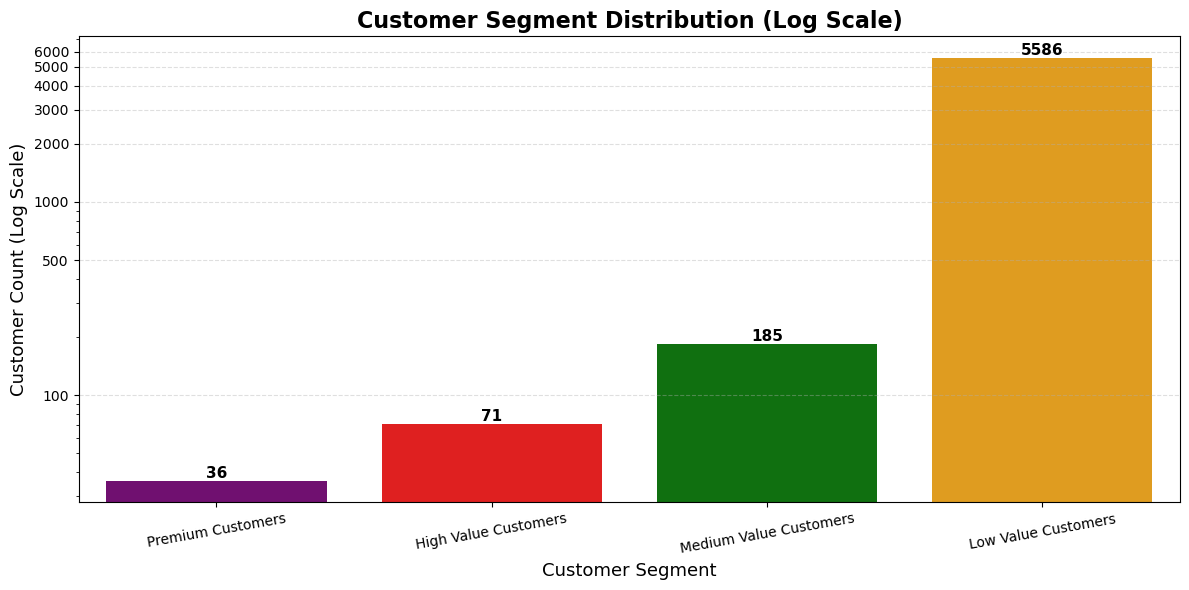


Customer Segment Summary:

         Customer Segment  Count  Percentage (%)
0       Premium Customers     36            0.61
1    High Value Customers     71            1.21
2  Medium Value Customers    185            3.15
3     Low Value Customers   5586           95.03


In [44]:
plt.figure(figsize=(12,6))

order = [
    'Premium Customers',
    'High Value Customers',
    'Medium Value Customers',
    'Low Value Customers'
]

colors = ['purple', 'red', 'green', 'orange']

ax = sns.countplot(
    x='CustomerSegment',
    data=customer_df,
    order=order,
    palette=colors
)

# Add labels above bars
for p in ax.patches:

    height = p.get_height()

    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width()/2., height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# IMPORTANT PART
# Makes smaller bars visible
ax.set_yscale('log')

# Custom Y-axis labels
ax.set_yticks([100, 500, 1000, 2000, 3000, 4000,5000,6000])
ax.set_yticklabels(['100', '500','1000', '2000', '3000', '4000','5000','6000'])

# Titles and labels
plt.title(
    'Customer Segment Distribution (Log Scale)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Segment', fontsize=13)
plt.ylabel('Customer Count (Log Scale)', fontsize=13)

plt.xticks(rotation=10)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()


# -------------------------------
# Segment Summary Table
# -------------------------------

segment_counts = customer_df['CustomerSegment'].value_counts().reindex(order)

segment_summary = pd.DataFrame({
    'Customer Segment': segment_counts.index,
    'Count': segment_counts.values,
    'Percentage (%)': (
        segment_counts.values / segment_counts.sum() * 100
    ).round(2)
})

print("\nCustomer Segment Summary:\n")
print(segment_summary)

In [45]:
# Saving final prediction CSV
customer_df.to_csv(
    'Final_LTV_Predictions.csv',
    index=False
)

print('Final CSV Saved Successfully')

Final CSV Saved Successfully


In [46]:
joblib.dump(xgb_model, 'ltv_prediction_model.pkl')

print('Model Saved Successfully')

Model Saved Successfully


In [47]:
joblib.dump(scaler, 'ltv_scaler.pkl')

print('Scaler Saved Successfully')

Scaler Saved Successfully
